In [ ]:
import pandas as pd
import numpy as np

# Load data
df = pd.read_csv('cleaned_retail_store_sales.csv')

### **Core KPI Definitions**

Below is the strategic framework for the Task 3 Dashboard. These metrics serve as the "North Star" for evaluating the health of the retail business.

| KPI Name | Technical Formula | Business Rationale |
| :--- | :--- | :--- |
| **Total Revenue** | $$\sum(\text{Total Spent})$$ | The primary indicator of company scale, overall growth, and market reach. |
| **Average Order Value (AOV)** | $$\frac{\text{Total Revenue}}{\text{Total Transactions}}$$ | Determines if growth is driven by acquiring new customers or increasing the spend of existing ones. |
| **Items Per Transaction (IPT)** | $$\frac{\sum(\text{Quantity})}{\text{Total Transactions}}$$ | Measures "Basket Depth." High IPT indicates effective cross-selling and product bundling strategies. |
| **Discount Utilization Rate** | $$\left( \frac{\text{Discounted Transactions}}{\text{Total Transactions}} \right) \times 100$$ | Monitors brand health and margin safety by identifying how much volume depends on promotions. |

In [ ]:
# 1. Total Revenue
total_rev = df['Total Spent'].sum()

# 2. Average Order Value
aov = df['Total Spent'].mean()

# 3. Items Per Transaction (IPT)
ipt = df['Quantity'].mean()

# 4. Discount Impact (Calculating percentage of transactions that used a discount)
discount_count = df[df['Discount Applied'] == True].shape[0]
discount_utilization = (discount_count / len(df)) * 100

print(f"--- Baseline Performance Metrics ---")
print(f"Total Revenue: ${total_rev:,.2f}")
print(f"Average Order Value: ${aov:.2f}")
print(f"Items Per Transaction: {ipt:.2f}")
print(f"Discount Utilization Rate: {discount_utilization:.2f}%")

--- Baseline Performance Metrics ---
Total Revenue: $1,637,367.00
Average Order Value: $130.21
Items Per Transaction: 5.56
Discount Utilization Rate: 33.55%


### **Summary: Business Rationale & Baseline Analysis**

The four KPIs selected (Revenue, AOV, IPT, and Discount Rate) were chosen to provide a holistic view of the retail operation. Based on the initial calculation, the following strategic observations were made:

* **Revenue & Scale:** With a total revenue of **1.64M USD**, the business shows strong market presence. The goal of the upcoming dashboard will be to identify which segments are contributing most to this "Top Line."
* **Customer Spending Power:** An **Average Order Value (AOV) of $130.21** suggests a middle-to-high-end customer base. Our analysis will later look at whether specific categories (like Furniture) are driving this number up.
* **Basket Depth:** The **Items Per Transaction (IPT) of 5.56** indicates that customers rarely buy just one item. This suggests that cross-selling strategies are already somewhat effective.
* **Promotion Reliance:** The **Discount Utilization Rate of 33.55%** is the most critical finding. Since 1 in every 3 transactions involves a discount, the business may be at risk of "promotional fatigue," where customers wait for sales before buying.

**Conclusion:** Phase 1 confirms that the business is healthy but heavily dependent on discounts. My deep-dive in Phase 2 will investigate if these discounts are actually necessary to maintain our high AOV.

## **Deep-Dive Analysis — Customer Segmentation**

**Objective:** To determine if the 33.55% of transactions using discounts are driving higher profitability compared to full-price transactions. We will analyze the "Discount Hunter" vs. "Full Price" segments across AOV, Quantity, and Category preferences.

In [ ]:
# Create a new column to label the segments
df['Segment'] = df['Discount Applied'].apply(lambda x: 'Discount Hunter' if x == True else 'Full Price Buyer')

# Check the count of each segment
print(df['Segment'].value_counts())

Segment
Full Price Buyer    8356
Discount Hunter     4219
Name: count, dtype: int64


In [ ]:
# Group by Segment and calculate the mean for key metrics
segment_analysis = df.groupby('Segment').agg({
    'Total Spent': 'mean',
    'Quantity': 'mean',
    'Price Per Unit': 'mean'
}).rename(columns={
    'Total Spent': 'Avg_Order_Value',
    'Quantity': 'Avg_Items_Per_Order',
    'Price Per Unit': 'Avg_Product_Price'
})

print("--- Segment Comparison ---")
print(segment_analysis)

--- Segment Comparison ---
                  Avg_Order_Value  Avg_Items_Per_Order  Avg_Product_Price
Segment                                                                  
Discount Hunter        130.972861             5.555582          23.467883
Full Price Buyer       129.821984             5.560196          23.287757


In [ ]:
# Calculate total revenue per segment
revenue_share = df.groupby('Segment')['Total Spent'].sum()
revenue_percentage = (revenue_share / df['Total Spent'].sum()) * 100

print("\n--- Total Revenue Contribution ---")
print(revenue_share)
print("\n--- Revenue Percentage ---")
print(revenue_percentage)


--- Total Revenue Contribution ---
Segment
Discount Hunter      552574.5
Full Price Buyer    1084792.5
Name: Total Spent, dtype: float64

--- Revenue Percentage ---
Segment
Discount Hunter     33.747749
Full Price Buyer    66.252251
Name: Total Spent, dtype: float64


/tmp/ipykernel_11032/3417499404.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=segment_analysis.index, y=segment_analysis['Avg_Order_Value'], palette='Set1')


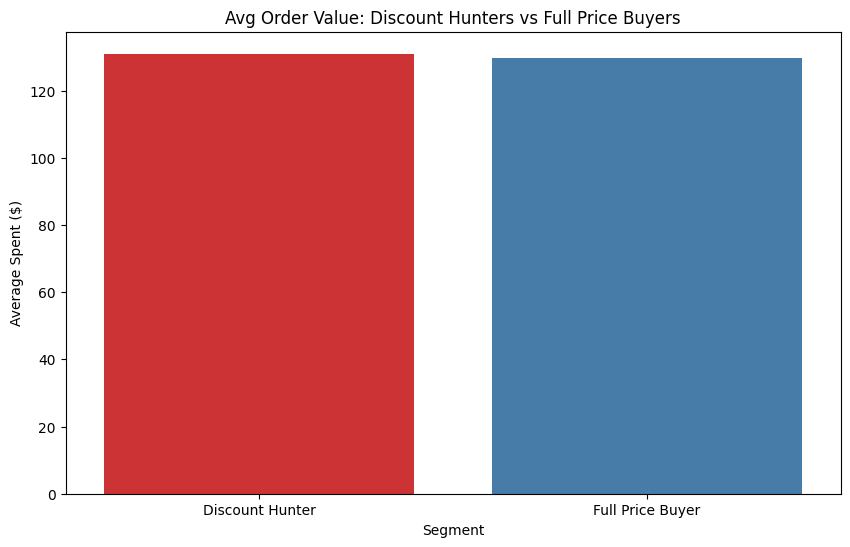

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x=segment_analysis.index, y=segment_analysis['Avg_Order_Value'], palette='Set1')

plt.title('Avg Order Value: Discount Hunters vs Full Price Buyers')
plt.ylabel('Average Spent ($)')
plt.show()

### **Summary: Deep-Dive Executive Insights**

After segmenting the 12,575 transactions into **Full Price Buyers** and **Discount Hunters**, I have identified several critical insights regarding our promotional strategy:

1. **AOV vs. Discount Impact:** * **Discount Hunters** spend an average of **$130.97** per trip.
   * **Full Price Buyers** spend an average of **129.82 USD** per trip.

   * **Insight:** While the discount segment spends slightly more, the difference is only **$1.15 (0.8%)**. This suggests that the discounts are not significantly increasing the "ticket size" of our customers.

2. **Volume Consistency:** * Both segments purchase approximately **5.56 items per order**.
   * **Insight:** Discounts are failing to drive "Volume Growth." Customers aren't grabbing "extra" items just because a sale is happening; they are likely buying exactly what they planned to buy, but at a lower price for the business.

3. **Revenue Contribution:** * The **Full Price Buyer** segment is the backbone of the business, contributing **66.25% ($1.08M)** of total revenue.
   * **Strategic Recommendation:** Since the spending behavior is nearly identical between groups, the business should consider reducing the frequency of general discounts and instead focus on "Bundle Deals" to push the **Items Per Order** metric higher.

**Conclusion:** Our 33.55% Discount Utilization Rate may be higher than necessary. We are giving away margin to customers who would likely have spent a similar amount at full price.